# Week 5 — Experiment 04: Matérn 3/2 optimizer robustness

This notebook holds the selected Gaussian Process model fixed and changes only the hyperparameter optimizer. It compares L-BFGS-B, SLSQP, Powell and a no-optimization sanity baseline under simulation-level leave-one-out cross-validation (LOO).

The purpose is optimizer robustness, not a new kernel search. The regression response remains the first actually observed Conduction raw timestep.


## 1. Fixed model and fair optimizer policy

Every optimized fit uses:

- `ConstantKernel(1.0, bounds=(1e-3, 1e3)) × Matern(length_scale=1.0, bounds=(1e-2, 1e2), nu=1.5)`;
- fold-local `StandardScaler` on `P`, `VX`, `LS`, `ST`;
- `normalize_y=True`, `alpha=1e-6`, no `WhiteKernel`;
- the common initial log-hyperparameter vector `[0, 0]`;
- one common deterministic extra restart generated from the same seed and bounds;
- maximum 200 optimizer iterations and an objective tolerance of `1e-9` where supported.

L-BFGS-B and SLSQP receive the analytic gradient from the GP objective. Powell receives function values only. The no-optimization baseline keeps the initial kernel and has no restart.


In [1]:
from __future__ import annotations

import hashlib
import json
import math
import platform
import time
import warnings
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
from IPython.display import Markdown, display
from scipy.optimize import minimize
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern
from sklearn.metrics import r2_score
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler

def find_repository_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / ".git").exists() and (candidate / "requirements.txt").exists():
            return candidate
    raise RuntimeError("Could not locate repository root")

ROOT = find_repository_root()
RAW_PATH = ROOT / "data" / "raw" / "sph_dataset" / "final-labels_all.csv"
AUDIT_PATH = ROOT / "outputs" / "week5_01_first_conduction_data_audit" / "simulation_level_audit.csv"
PHASE2_CLEAN_METRICS = ROOT / "outputs" / "week5_02_first_conduction_gp_kernel_comparison" / "clean" / "clean_kernel_metrics.csv"
PHASE2_BROAD_METRICS = ROOT / "outputs" / "week5_02_first_conduction_gp_kernel_comparison" / "broad" / "broad_kernel_metrics.csv"
OUTPUT_ROOT = ROOT / "outputs" / "week5_04_matern32_optimizer_comparison"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

INPUTS = ["P", "VX", "LS", "ST"]
TARGET = "first_observed_conduction_timestep"
EXPECTED_SHA256 = "964a12d86435e9f0879e2e43384d997e1cc2faa7b9e4c3aeb49cf0e73e3fb154"
RANDOM_SEED = 20260722
ALPHA = 1e-6
NORMALIZE_Y = True
CONSTANT_INITIAL = 1.0
CONSTANT_BOUNDS = (1e-3, 1e3)
LENGTHSCALE_INITIAL = 1.0
LENGTHSCALE_BOUNDS = (1e-2, 1e2)
MAXITER = 200
OBJECTIVE_FTOL = 1e-9
GRADIENT_GTOL = 1e-6
POWELL_XTOL = 1e-6
OPTIMIZER_ORDER = ["lbfgsb", "slsqp", "powell", "none"]
OPTIMIZER_LABELS = {
    "lbfgsb": "L-BFGS-B",
    "slsqp": "SLSQP",
    "powell": "Powell",
    "none": "No optimization",
}
OPTIMIZER_COLORS = {
    "lbfgsb": "#2563EB",
    "slsqp": "#7C3AED",
    "powell": "#0F766E",
    "none": "#F59E0B",
}
INTERVAL_Z = 1.959963984540054

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 160,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
pd.set_option("display.max_columns", 60)
pd.set_option("display.precision", 6)
display(pd.DataFrame({
    "item": ["Python", "scikit-learn", "SciPy", "seed", "max iterations", "output root"],
    "value": [platform.python_version(), sklearn.__version__, scipy.__version__, RANDOM_SEED, MAXITER, str(OUTPUT_ROOT)],
}))


,item,value
0,Python,3.12.13
1,scikit-learn,1.9.0
2,SciPy,1.18.0
3,seed,20260722
4,max iterations,200
5,output root,C:\Users\ozgur\Documents\thesis-week5-first-co...


## 2. Load the same clean/no-Bug and broad simulation-level datasets


In [2]:
raw_sha256 = hashlib.sha256(RAW_PATH.read_bytes()).hexdigest()
if raw_sha256 != EXPECTED_SHA256:
    raise ValueError(f"Raw SHA-256 changed: {raw_sha256}")

audit = pd.read_csv(AUDIT_PATH)
clean_data = audit.loc[audit["reaches_conduction"] & ~audit["screenshot_bug_any"]].copy().reset_index(drop=True)
broad_data = audit.loc[audit["reaches_conduction"]].copy().reset_index(drop=True)
if len(clean_data) != 91 or len(broad_data) != 238:
    raise ValueError(f"Unexpected counts: clean={len(clean_data)}, broad={len(broad_data)}")
if clean_data["name"].duplicated().any() or broad_data["name"].duplicated().any():
    raise ValueError("Simulation names must be unique")
if clean_data[TARGET].isna().any() or broad_data[TARGET].isna().any():
    raise ValueError("Modelling datasets contain undefined targets")

display(pd.DataFrame({
    "dataset": ["clean/no-Bug", "broad"],
    "simulations": [len(clean_data), len(broad_data)],
    "target_min": [clean_data[TARGET].min(), broad_data[TARGET].min()],
    "target_median": [clean_data[TARGET].median(), broad_data[TARGET].median()],
    "target_max": [clean_data[TARGET].max(), broad_data[TARGET].max()],
}))


,dataset,simulations,target_min,target_median,target_max
0,clean/no-Bug,91,4840.0,13933.0,42436.0
1,broad,238,4840.0,29019.0,95798.0


**Interpretation.** The sample counts and target distributions match Phase 2. “Clean” remains only the operational name for the no-Screenshot-Bug subgroup; it is not assumed to be a confirmed higher-quality sample.


## 3. Optimizer wrappers and recorded restart diagnostics


In [3]:
def make_kernel(nu: float = 1.5):
    return ConstantKernel(CONSTANT_INITIAL, CONSTANT_BOUNDS) * Matern(
        length_scale=LENGTHSCALE_INITIAL,
        length_scale_bounds=LENGTHSCALE_BOUNDS,
        nu=nu,
    )

def make_optimizer_callable(optimizer_name: str, run_records: list[dict]):
    def optimizer(objective, initial_theta, bounds):
        start_theta = np.asarray(initial_theta, dtype=float).copy()
        began = time.perf_counter()
        fallback_used = False
        exception_text = ""
        try:
            if optimizer_name == "lbfgsb":
                result = minimize(
                    lambda theta: objective(theta, eval_gradient=True),
                    start_theta,
                    method="L-BFGS-B",
                    jac=True,
                    bounds=bounds,
                    options={"maxiter": MAXITER, "ftol": OBJECTIVE_FTOL, "gtol": GRADIENT_GTOL},
                )
            elif optimizer_name == "slsqp":
                result = minimize(
                    lambda theta: objective(theta, eval_gradient=True),
                    start_theta,
                    method="SLSQP",
                    jac=True,
                    bounds=bounds,
                    options={"maxiter": MAXITER, "ftol": OBJECTIVE_FTOL},
                )
            elif optimizer_name == "powell":
                result = minimize(
                    lambda theta: objective(theta, eval_gradient=False),
                    start_theta,
                    method="Powell",
                    bounds=bounds,
                    options={"maxiter": MAXITER, "ftol": OBJECTIVE_FTOL, "xtol": POWELL_XTOL},
                )
            else:
                raise ValueError(optimizer_name)
            result_theta = np.asarray(result.x, dtype=float)
            result_objective = float(result.fun)
            finite = np.isfinite(result_theta).all() and np.isfinite(result_objective)
            if not finite:
                raise FloatingPointError("optimizer returned a non-finite parameter or objective")
            success = bool(result.success)
            message = str(result.message)
            iterations = int(getattr(result, "nit", -1))
            function_evaluations = int(getattr(result, "nfev", -1))
            gradient_evaluations = int(getattr(result, "njev", -1))
        except Exception as exc:
            fallback_used = True
            exception_text = f"{type(exc).__name__}: {exc}"
            result_theta = start_theta.copy()
            result_objective = float(objective(start_theta, eval_gradient=False))
            success = False
            message = "invalid optimizer result; retained this run's own start point"
            iterations = -1
            function_evaluations = -1
            gradient_evaluations = -1

        run_records.append({
            "optimizer": optimizer_name,
            "start_index": len(run_records),
            "start_theta": start_theta.tolist(),
            "result_theta": result_theta.tolist(),
            "objective": result_objective,
            "success": success,
            "message": message,
            "iterations": iterations,
            "function_evaluations": function_evaluations,
            "gradient_evaluations": gradient_evaluations,
            "runtime_seconds": time.perf_counter() - began,
            "fallback_used": fallback_used,
            "exception": exception_text,
        })
        return result_theta, result_objective
    return optimizer

def bound_diagnostics(theta: np.ndarray, bounds: np.ndarray, tolerance: float = 1e-5) -> tuple[int, str]:
    names = ["signal_variance", "lengthscale"]
    hits = []
    for index, name in enumerate(names):
        if abs(theta[index] - bounds[index, 0]) <= tolerance:
            hits.append(f"{name}:lower")
        if abs(theta[index] - bounds[index, 1]) <= tolerance:
            hits.append(f"{name}:upper")
    return len(hits), ";".join(hits)


**Failure policy.** Every optimizer run is retained, including unsuccessful restarts. A non-finite or exceptional run may fall back only to its own starting point. If the complete GP fit still fails, the fold is explicitly marked and an initial-kernel, no-optimization fit is used only to construct a traceable prediction artifact. L-BFGS-B is never substituted for another optimizer.


## 4. Runtime and interface smoke test


In [4]:
def fit_predict_one(
    dataset_name: str,
    fold_index: int,
    optimizer_name: str,
    train: pd.DataFrame,
    heldout: pd.DataFrame,
    nu: float = 1.5,
) -> tuple[dict, list[dict]]:
    scaler = StandardScaler().fit(train[INPUTS])
    X_train = scaler.transform(train[INPUTS])
    X_heldout = scaler.transform(heldout[INPUTS])
    y_train = train[TARGET].to_numpy(float)
    run_records: list[dict] = []
    fit_failed = False
    fit_failure_message = ""
    fallback_fit_used = False
    optimizer_callable = None if optimizer_name == "none" else make_optimizer_callable(optimizer_name, run_records)
    model = GaussianProcessRegressor(
        kernel=make_kernel(nu=nu),
        alpha=ALPHA,
        normalize_y=NORMALIZE_Y,
        optimizer=optimizer_callable,
        n_restarts_optimizer=0 if optimizer_name == "none" else 1,
        random_state=RANDOM_SEED,
    )

    began = time.perf_counter()
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        try:
            model.fit(X_train, y_train)
        except Exception as exc:
            fit_failed = True
            fit_failure_message = f"{type(exc).__name__}: {exc}"
            fallback_fit_used = True
            model = GaussianProcessRegressor(
                kernel=make_kernel(nu=nu), alpha=ALPHA, normalize_y=NORMALIZE_Y,
                optimizer=None, n_restarts_optimizer=0, random_state=RANDOM_SEED,
            ).fit(X_train, y_train)
        fit_seconds = time.perf_counter() - began
        predict_began = time.perf_counter()
        predicted_mean, predicted_std = model.predict(X_heldout, return_std=True)
        predict_seconds = time.perf_counter() - predict_began

    if optimizer_name == "none" or fallback_fit_used:
        selected_run_success = True if optimizer_name == "none" and not fit_failed else False
        selected_start_index = -1
    else:
        selected = min(run_records, key=lambda record: record["objective"])
        selected_run_success = bool(selected["success"])
        selected_start_index = int(selected["start_index"])

    theta = np.asarray(model.kernel_.theta, dtype=float)
    bounds = np.asarray(model.kernel_.bounds, dtype=float)
    bound_hit_count, bound_hit_parameters = bound_diagnostics(theta, bounds)
    observed = float(heldout[TARGET].iloc[0])
    mean = float(predicted_mean[0])
    std = float(predicted_std[0])
    std_safe = max(std, 1e-12)
    residual = observed - mean
    lower = mean - INTERVAL_Z * std
    upper = mean + INTERVAL_Z * std
    warning_messages = [f"{type(item.message).__name__}: {item.message}" for item in caught]
    starts = [record["start_theta"] for record in run_records]
    objectives = [record["objective"] for record in run_records]

    row = {
        "dataset": dataset_name,
        "fold_index": fold_index,
        "name": heldout["name"].iloc[0],
        "optimizer": optimizer_name,
        "optimizer_label": OPTIMIZER_LABELS[optimizer_name],
        "P": float(heldout["P"].iloc[0]), "VX": float(heldout["VX"].iloc[0]),
        "LS": float(heldout["LS"].iloc[0]), "ST": float(heldout["ST"].iloc[0]),
        "observed_target": observed,
        "predicted_mean": mean,
        "predicted_std": std,
        "residual_observed_minus_predicted": residual,
        "absolute_error": abs(residual),
        "squared_error": residual ** 2,
        "negative_log_predictive_density": 0.5 * math.log(2 * math.pi * std_safe ** 2) + 0.5 * (residual / std_safe) ** 2,
        "lower_95": lower, "upper_95": upper,
        "covered_95": bool(lower <= observed <= upper),
        "interval_width_95": upper - lower,
        "training_simulations": len(train),
        "scaler_fit_rows": len(train),
        "heldout_in_scaler_fit": False,
        "alpha_jitter": ALPHA,
        "normalize_y": NORMALIZE_Y,
        "initial_signal_variance": CONSTANT_INITIAL,
        "initial_lengthscale": LENGTHSCALE_INITIAL,
        "extra_restart_count": 0 if optimizer_name == "none" else 1,
        "random_seed": RANDOM_SEED,
        "max_iterations": MAXITER,
        "fit_runtime_seconds": fit_seconds,
        "predict_runtime_seconds": predict_seconds,
        "fold_runtime_seconds": fit_seconds + predict_seconds,
        "optimizer_convergence_applicable": optimizer_name != "none",
        "optimizer_selected_run_success": selected_run_success,
        "optimizer_selected_start_index": selected_start_index,
        "optimizer_run_count": len(run_records),
        "optimizer_unsuccessful_run_count": sum(not record["success"] for record in run_records),
        "optimizer_fallback_run_count": sum(record["fallback_used"] for record in run_records),
        "optimizer_start_thetas_json": json.dumps(starts),
        "optimizer_objectives_json": json.dumps(objectives),
        "optimizer_runs_json": json.dumps(run_records),
        "warning_count": len(warning_messages),
        "warning_messages": " | ".join(warning_messages),
        "fit_failed": fit_failed,
        "fit_failure_message": fit_failure_message,
        "fallback_fit_used": fallback_fit_used,
        "parameter_bound_hit_count": bound_hit_count,
        "parameter_bound_hit_parameters": bound_hit_parameters,
        "optimized_kernel_expression": str(model.kernel_),
        "log_marginal_likelihood_train_fold": float(model.log_marginal_likelihood_value_),
        "signal_variance": float(np.exp(theta[0])),
        "lengthscale": float(np.exp(theta[1])),
        **{f"scaler_training_mean_{column}": float(value) for column, value in zip(INPUTS, scaler.mean_)},
        **{f"scaler_training_scale_{column}": float(value) for column, value in zip(INPUTS, scaler.scale_)},
    }
    return row, run_records

smoke_rows = []
for dataset_name, data in [("clean", clean_data), ("broad", broad_data)]:
    train = data.iloc[1:].copy()
    heldout = data.iloc[[0]].copy()
    for optimizer_name in OPTIMIZER_ORDER:
        row, _ = fit_predict_one(dataset_name, 0, optimizer_name, train, heldout)
        smoke_rows.append(row)
optimizer_smoke_results = pd.DataFrame(smoke_rows)
optimizer_smoke_results.to_csv(OUTPUT_ROOT / "optimizer_smoke_results.csv", index=False)
display(optimizer_smoke_results[["dataset", "optimizer_label", "fold_runtime_seconds", "predicted_mean", "predicted_std", "optimizer_selected_run_success", "parameter_bound_hit_count"]])


,dataset,optimizer_label,fold_runtime_seconds,predicted_mean,predicted_std,optimizer_selected_run_success,parameter_bound_hit_count
0,clean,L-BFGS-B,0.052398,15759.908885,823.310535,True,0
1,clean,SLSQP,0.034580,15759.908885,823.310465,True,0
2,clean,Powell,0.246011,15759.908885,823.310456,True,0
3,clean,No optimization,0.002205,15766.369148,1377.278226,True,0
4,broad,L-BFGS-B,0.399521,16913.160314,6311.657519,True,0
5,broad,SLSQP,0.101008,16913.161993,6311.667639,True,0
6,broad,Powell,0.864845,16913.160314,6311.657589,True,0
7,broad,No optimization,0.005805,16267.566116,3436.824059,True,0


In [5]:
smoke_estimates = []
for optimizer_name in OPTIMIZER_ORDER:
    clean_seconds = optimizer_smoke_results.query("dataset == 'clean' and optimizer == @optimizer_name")["fold_runtime_seconds"].iloc[0]
    broad_seconds = optimizer_smoke_results.query("dataset == 'broad' and optimizer == @optimizer_name")["fold_runtime_seconds"].iloc[0]
    smoke_estimates.append({
        "optimizer": optimizer_name,
        "estimated_full_clean_plus_broad_LOO_seconds": clean_seconds * len(clean_data) + broad_seconds * len(broad_data),
    })
smoke_estimates = pd.DataFrame(smoke_estimates)
display(smoke_estimates)
display(Markdown(f'''The smoke estimate for all four LOO configurations is **{smoke_estimates['estimated_full_clean_plus_broad_LOO_seconds'].sum():.1f} seconds** before plotting and full-data fits. The same settings will now be used for every fold; no optimizer receives an extra start.'''))


,optimizer,estimated_full_clean_plus_broad_LOO_seconds
0,lbfgsb,99.854317
1,slsqp,27.186702
2,powell,228.220161
3,none,1.582313


The smoke estimate for all four LOO configurations is **356.8 seconds** before plotting and full-data fits. The same settings will now be used for every fold; no optimizer receives an extra start.

## 5. Manual simulation-level LOO


In [6]:
def run_dataset_loo(dataset_name: str, data: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, float]:
    prediction_rows = []
    optimizer_run_rows = []
    began = time.perf_counter()
    splitter = LeaveOneOut()
    for fold_index, (train_index, heldout_index) in enumerate(splitter.split(data)):
        train = data.iloc[train_index].copy()
        heldout = data.iloc[heldout_index].copy()
        for optimizer_name in OPTIMIZER_ORDER:
            row, run_records = fit_predict_one(dataset_name, fold_index, optimizer_name, train, heldout)
            prediction_rows.append(row)
            for run in run_records:
                optimizer_run_rows.append({
                    "dataset": dataset_name,
                    "fold_index": fold_index,
                    "name": heldout["name"].iloc[0],
                    **run,
                })
        if (fold_index + 1) % 25 == 0 or fold_index + 1 == len(data):
            print(f"{dataset_name}: completed {fold_index + 1}/{len(data)} held-out simulations", flush=True)
    return pd.DataFrame(prediction_rows), pd.DataFrame(optimizer_run_rows), time.perf_counter() - began

clean_predictions, clean_optimizer_runs, clean_loo_wall_seconds = run_dataset_loo("clean", clean_data)
broad_predictions, broad_optimizer_runs, broad_loo_wall_seconds = run_dataset_loo("broad", broad_data)
clean_predictions.to_csv(OUTPUT_ROOT / "clean_optimizer_loo_predictions.csv", index=False)
broad_predictions.to_csv(OUTPUT_ROOT / "broad_optimizer_loo_predictions.csv", index=False)

optimizer_run_details = pd.concat([clean_optimizer_runs, broad_optimizer_runs], ignore_index=True)
print(f"clean LOO wall seconds: {clean_loo_wall_seconds:.1f}")
print(f"broad LOO wall seconds: {broad_loo_wall_seconds:.1f}")


clean: completed 25/91 held-out simulations


clean: completed 50/91 held-out simulations


clean: completed 75/91 held-out simulations


clean: completed 91/91 held-out simulations


broad: completed 25/238 held-out simulations


...

broad: completed 175/238 held-out simulations


broad: completed 200/238 held-out simulations


broad: completed 225/238 held-out simulations


broad: completed 238/238 held-out simulations


clean LOO wall seconds: 28.1
broad LOO wall seconds: 296.8


**Interpretation.** Every held-out prediction uses a scaler and GP fitted only on the remaining simulations. The prediction files retain start vectors, objective values, convergence state, warnings, bound hits and runtime for auditability.


## 6. Held-out metrics and optimizer diagnostics


In [7]:
def calculate_optimizer_metrics(predictions: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for optimizer_name, group in predictions.groupby("optimizer", sort=False, observed=True):
        y = group["observed_target"].to_numpy(float)
        mean = group["predicted_mean"].to_numpy(float)
        residual = y - mean
        rmse = float(np.sqrt(np.mean(residual ** 2)))
        target_std = float(np.std(y, ddof=1))
        convergence_applicable = group["optimizer_convergence_applicable"]
        rows.append({
            "dataset": group["dataset"].iloc[0],
            "optimizer": optimizer_name,
            "optimizer_label": OPTIMIZER_LABELS[optimizer_name],
            "simulations": len(group),
            "MAE": float(np.mean(np.abs(residual))),
            "median_absolute_error": float(np.median(np.abs(residual))),
            "RMSE": rmse,
            "R2": float(r2_score(y, mean)),
            "target_sample_std": target_std,
            "normalized_RMSE": rmse / target_std,
            "mean_negative_log_predictive_density": float(group["negative_log_predictive_density"].mean()),
            "empirical_95_interval_coverage": float(group["covered_95"].mean()),
            "coverage_error_from_0_95": abs(float(group["covered_95"].mean()) - 0.95),
            "mean_95_interval_width": float(group["interval_width_95"].mean()),
            "total_runtime_seconds": float(group["fold_runtime_seconds"].sum()),
            "median_runtime_per_fold_seconds": float(group["fold_runtime_seconds"].median()),
            "convergence_success_count": int((group["optimizer_selected_run_success"] & convergence_applicable).sum()),
            "convergence_unsuccessful_count": int((~group["optimizer_selected_run_success"] & convergence_applicable).sum()),
            "convergence_not_applicable_count": int((~convergence_applicable).sum()),
            "warning_count": int(group["warning_count"].sum()),
            "failure_count": int(group["fit_failed"].sum()),
            "fallback_fit_count": int(group["fallback_fit_used"].sum()),
            "folds_with_parameter_bound_hit": int(group["parameter_bound_hit_count"].gt(0).sum()),
            "unsuccessful_optimizer_runs_all_starts": int(group["optimizer_unsuccessful_run_count"].sum()),
        })
    return pd.DataFrame(rows).set_index("optimizer").loc[OPTIMIZER_ORDER].reset_index()

clean_metrics = calculate_optimizer_metrics(clean_predictions)
broad_metrics = calculate_optimizer_metrics(broad_predictions)
clean_metrics.to_csv(OUTPUT_ROOT / "clean_optimizer_metrics.csv", index=False)
broad_metrics.to_csv(OUTPUT_ROOT / "broad_optimizer_metrics.csv", index=False)
display(clean_metrics.round(6))
display(broad_metrics.round(6))


,optimizer,dataset,optimizer_label,simulations,MAE,median_absolute_error,RMSE,R2,target_sample_std,normalized_RMSE,mean_negative_log_predictive_density,empirical_95_interval_coverage,coverage_error_from_0_95,mean_95_interval_width,total_runtime_seconds,median_runtime_per_fold_seconds,convergence_success_count,convergence_unsuccessful_count,convergence_not_applicable_count,warning_count,failure_count,fallback_fit_count,folds_with_parameter_bound_hit,unsuccessful_optimizer_runs_all_starts
0,lbfgsb,clean,L-BFGS-B,91,1735.765231,1092.086680,2537.006918,0.917113,8860.906678,0.286315,9.815631,0.901099,0.048901,13861.925251,3.390139,0.036432,91,0,0,0,0,0,0,0
1,slsqp,clean,SLSQP,91,1735.765095,1092.086759,2537.006767,0.917113,8860.906678,0.286315,9.815630,0.901099,0.048901,13861.924576,4.181168,0.045104,91,0,0,0,0,0,0,0
2,powell,clean,Powell,91,1735.765126,1092.086557,2537.006734,0.917113,8860.906678,0.286315,9.815630,0.901099,0.048901,13861.925627,18.863839,0.205014,91,0,0,0,0,0,0,0
3,none,clean,No optimization,91,1899.214800,1317.167768,2770.378128,0.901163,8860.906678,0.312652,9.598310,0.945055,0.004945,17879.668770,0.168564,0.001688,0,0,91,0,0,0,0,0


,optimizer,dataset,optimizer_label,simulations,MAE,median_absolute_error,RMSE,R2,target_sample_std,normalized_RMSE,mean_negative_log_predictive_density,empirical_95_interval_coverage,coverage_error_from_0_95,mean_95_interval_width,total_runtime_seconds,median_runtime_per_fold_seconds,convergence_success_count,convergence_unsuccessful_count,convergence_not_applicable_count,warning_count,failure_count,fallback_fit_count,folds_with_parameter_bound_hit,unsuccessful_optimizer_runs_all_starts
0,lbfgsb,broad,L-BFGS-B,238,11616.870211,7414.184026,16256.261409,0.405976,21136.499888,0.769108,11.040433,0.928571,0.021429,58070.270945,76.653670,0.317460,238,0,0,0,0,0,0,0
1,slsqp,broad,SLSQP,238,11616.868777,7414.185001,16256.260691,0.405976,21136.499888,0.769108,11.040433,0.928571,0.021429,58070.291783,31.046725,0.155407,238,0,0,0,0,0,0,0
2,powell,broad,Powell,238,11616.870204,7414.184185,16256.261361,0.405976,21136.499888,0.769108,11.040433,0.928571,0.021429,58070.270876,184.107038,0.751552,238,0,0,0,0,0,0,0
3,none,broad,No optimization,238,11746.001464,7780.454205,16871.408714,0.360169,21136.499888,0.798212,11.414177,0.810924,0.139076,38435.226747,0.974226,0.004052,0,0,238,0,0,0,0,0


In [8]:
diagnostic_columns = [
    "dataset", "fold_index", "name", "optimizer", "optimizer_label", "training_simulations",
    "fit_runtime_seconds", "predict_runtime_seconds", "fold_runtime_seconds",
    "optimizer_convergence_applicable", "optimizer_selected_run_success", "optimizer_selected_start_index",
    "optimizer_run_count", "optimizer_unsuccessful_run_count", "optimizer_fallback_run_count",
    "optimizer_start_thetas_json", "optimizer_objectives_json", "optimizer_runs_json",
    "warning_count", "warning_messages", "fit_failed", "fit_failure_message", "fallback_fit_used",
    "parameter_bound_hit_count", "parameter_bound_hit_parameters", "optimized_kernel_expression",
    "log_marginal_likelihood_train_fold", "signal_variance", "lengthscale",
]
optimizer_fold_diagnostics = pd.concat([
    clean_predictions[diagnostic_columns], broad_predictions[diagnostic_columns]
], ignore_index=True)
optimizer_fold_diagnostics.to_csv(OUTPUT_ROOT / "optimizer_fold_diagnostics.csv", index=False)

hyperparameter_rows = []
for (dataset, optimizer_name), group in optimizer_fold_diagnostics.groupby(["dataset", "optimizer"], observed=True):
    hyperparameter_rows.append({
        "dataset": dataset,
        "optimizer": optimizer_name,
        "optimizer_label": OPTIMIZER_LABELS[optimizer_name],
        "folds": len(group),
        "signal_variance_min": group["signal_variance"].min(),
        "signal_variance_q25": group["signal_variance"].quantile(0.25),
        "signal_variance_median": group["signal_variance"].median(),
        "signal_variance_q75": group["signal_variance"].quantile(0.75),
        "signal_variance_max": group["signal_variance"].max(),
        "signal_variance_coefficient_of_variation": group["signal_variance"].std(ddof=1) / group["signal_variance"].mean(),
        "lengthscale_min": group["lengthscale"].min(),
        "lengthscale_q25": group["lengthscale"].quantile(0.25),
        "lengthscale_median": group["lengthscale"].median(),
        "lengthscale_q75": group["lengthscale"].quantile(0.75),
        "lengthscale_max": group["lengthscale"].max(),
        "lengthscale_coefficient_of_variation": group["lengthscale"].std(ddof=1) / group["lengthscale"].mean(),
        "folds_with_parameter_bound_hit": int(group["parameter_bound_hit_count"].gt(0).sum()),
    })
optimizer_hyperparameter_summary = pd.DataFrame(hyperparameter_rows)
optimizer_hyperparameter_summary.to_csv(OUTPUT_ROOT / "optimizer_hyperparameter_summary.csv", index=False)
display(optimizer_hyperparameter_summary.round(6))


,dataset,optimizer,optimizer_label,folds,signal_variance_min,signal_variance_q25,signal_variance_median,signal_variance_q75,signal_variance_max,signal_variance_coefficient_of_variation,lengthscale_min,lengthscale_q25,lengthscale_median,lengthscale_q75,lengthscale_max,lengthscale_coefficient_of_variation,folds_with_parameter_bound_hit
0,broad,lbfgsb,L-BFGS-B,238,1.005192,1.017768,1.019727,1.022255,1.045531,0.004632,0.610192,0.620816,0.621941,0.624154,0.670596,0.010293,0
1,broad,none,No optimization,238,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0
2,broad,powell,Powell,238,1.005192,1.017768,1.019727,1.022255,1.045531,0.004632,0.610192,0.620816,0.621941,0.624154,0.670596,0.010293,0
3,broad,slsqp,SLSQP,238,1.005192,1.017769,1.019728,1.022256,1.045532,0.004632,0.610192,0.620815,0.621941,0.624155,0.670596,0.010293,0
4,clean,lbfgsb,L-BFGS-B,91,0.759406,0.772220,0.774981,0.779072,0.854670,0.017136,1.118358,1.150016,1.155070,1.161664,1.467767,0.037959,0
5,clean,none,No optimization,91,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0
6,clean,powell,Powell,91,0.759406,0.772220,0.774981,0.779072,0.854670,0.017136,1.118358,1.150016,1.155070,1.161664,1.467767,0.037959,0
7,clean,slsqp,SLSQP,91,0.759406,0.772220,0.774981,0.779073,0.854670,0.017136,1.118358,1.150016,1.155071,1.161664,1.467767,0.037959,0


## 7. Paired prediction comparison against L-BFGS-B


In [9]:
pairwise_rows = []
paired_long_rows = []
for dataset, predictions in [("clean", clean_predictions), ("broad", broad_predictions)]:
    reference = predictions.loc[predictions["optimizer"].eq("lbfgsb")].set_index("name")
    for optimizer_name in ["slsqp", "powell", "none"]:
        candidate = predictions.loc[predictions["optimizer"].eq(optimizer_name)].set_index("name")
        shared = reference.index.intersection(candidate.index)
        prediction_difference = candidate.loc[shared, "predicted_mean"] - reference.loc[shared, "predicted_mean"]
        absolute_error_improvement = reference.loc[shared, "absolute_error"] - candidate.loc[shared, "absolute_error"]
        tolerance = 1e-9
        improved = absolute_error_improvement > tolerance
        worsened = absolute_error_improvement < -tolerance
        tied = ~(improved | worsened)
        reference_rmse = float(np.sqrt(reference.loc[shared, "squared_error"].mean()))
        candidate_rmse = float(np.sqrt(candidate.loc[shared, "squared_error"].mean()))
        pairwise_rows.append({
            "dataset": dataset,
            "reference_optimizer": "lbfgsb",
            "candidate_optimizer": optimizer_name,
            "heldout_simulations": len(shared),
            "mean_prediction_difference_candidate_minus_lbfgsb": float(prediction_difference.mean()),
            "mean_absolute_prediction_difference": float(np.abs(prediction_difference).mean()),
            "max_absolute_prediction_difference": float(np.abs(prediction_difference).max()),
            "prediction_difference_RMSE": float(np.sqrt(np.mean(prediction_difference ** 2))),
            "candidate_improved_absolute_error_count": int(improved.sum()),
            "candidate_worsened_absolute_error_count": int(worsened.sum()),
            "candidate_tied_absolute_error_count": int(tied.sum()),
            "median_absolute_error_improvement_lbfgsb_minus_candidate": float(absolute_error_improvement.median()),
            "reference_RMSE": reference_rmse,
            "candidate_RMSE": candidate_rmse,
            "candidate_RMSE_change_percent_vs_lbfgsb": 100 * (reference_rmse - candidate_rmse) / reference_rmse,
        })
        paired_long_rows.extend({
            "dataset": dataset,
            "name": name,
            "candidate_optimizer": optimizer_name,
            "prediction_difference_candidate_minus_lbfgsb": float(prediction_difference.loc[name]),
            "absolute_error_improvement_lbfgsb_minus_candidate": float(absolute_error_improvement.loc[name]),
        } for name in shared)
optimizer_pairwise_comparison = pd.DataFrame(pairwise_rows)
optimizer_pairwise_comparison.to_csv(OUTPUT_ROOT / "optimizer_pairwise_comparison.csv", index=False)
paired_long = pd.DataFrame(paired_long_rows)
display(optimizer_pairwise_comparison.round(8))


,dataset,reference_optimizer,candidate_optimizer,heldout_simulations,mean_prediction_difference_candidate_minus_lbfgsb,mean_absolute_prediction_difference,max_absolute_prediction_difference,prediction_difference_RMSE,candidate_improved_absolute_error_count,candidate_worsened_absolute_error_count,candidate_tied_absolute_error_count,median_absolute_error_improvement_lbfgsb_minus_candidate,reference_RMSE,candidate_RMSE,candidate_RMSE_change_percent_vs_lbfgsb
0,clean,lbfgsb,slsqp,91,0.000008,0.000308,0.005162,0.000703,50,41,0,0.000002,2537.006918,2537.006767,5.940000e-06
1,clean,lbfgsb,powell,91,0.000147,0.000210,0.005268,0.000729,41,50,0,-0.000002,2537.006918,2537.006734,7.270000e-06
2,clean,lbfgsb,none,91,3.238947,228.692176,926.769419,336.493869,32,59,0,-54.169951,2537.006918,2770.378128,-9.198682e+00
3,broad,lbfgsb,slsqp,238,0.000250,0.004680,0.057981,0.007531,131,107,0,0.000156,16256.261409,16256.260691,4.420000e-06
4,broad,lbfgsb,powell,238,-0.000031,0.000123,0.005752,0.000515,135,103,0,0.000002,16256.261409,16256.261361,3.000000e-07
5,broad,lbfgsb,none,238,253.320840,2512.404436,17428.581143,3611.349152,115,123,0,-63.566928,16256.261409,16871.408714,-3.784064e+00


**Interpretation.** Prediction differences are paired on exactly the same held-out simulations. Very small changes should not be described as substantive improvements merely because one RMSE is numerically lower.


## 8. Compact LOO figures


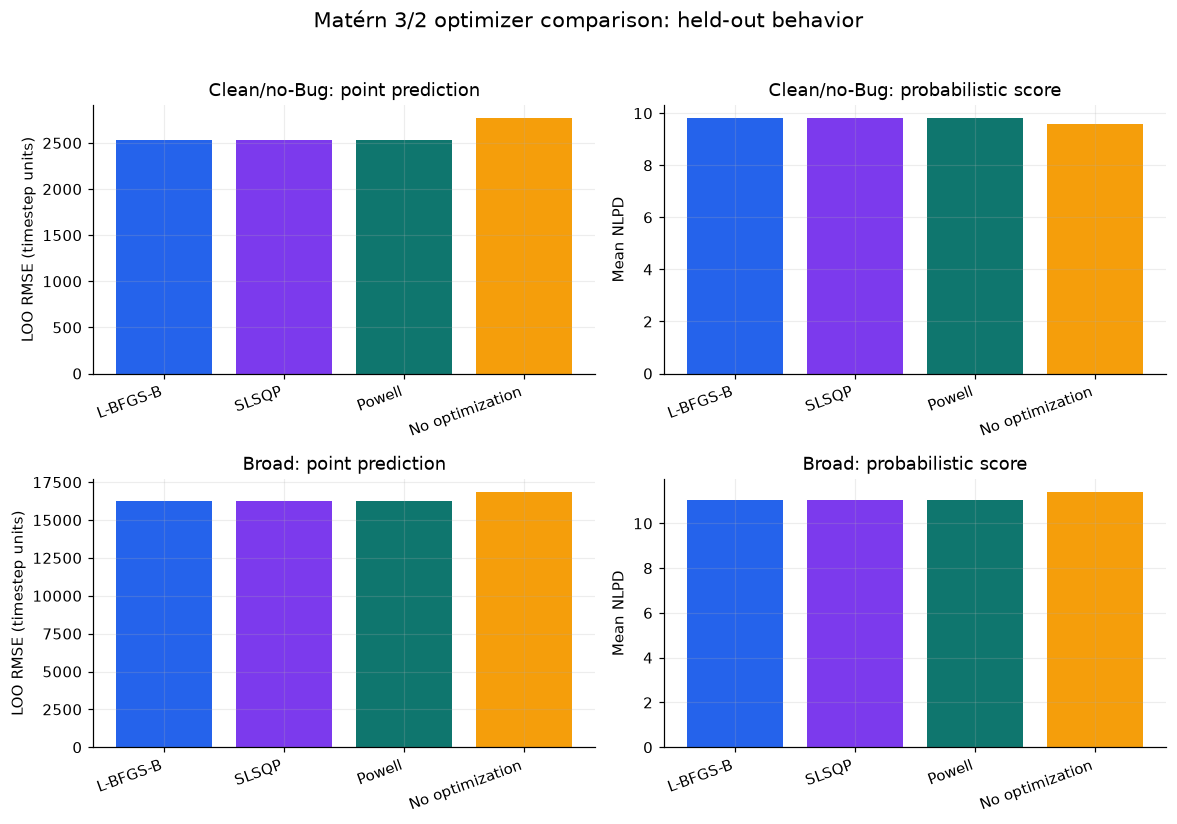

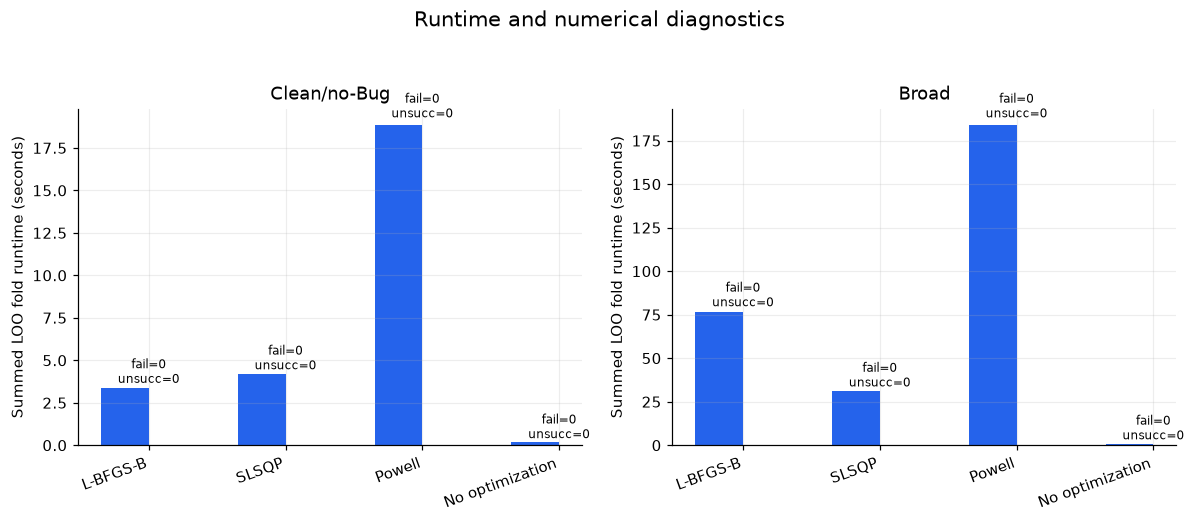

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(10.8, 7.6))
for row_index, (dataset, metrics) in enumerate([("Clean/no-Bug", clean_metrics), ("Broad", broad_metrics)]):
    ordered = metrics.set_index("optimizer").loc[OPTIMIZER_ORDER]
    x = np.arange(len(OPTIMIZER_ORDER))
    colors = [OPTIMIZER_COLORS[key] for key in OPTIMIZER_ORDER]
    axes[row_index, 0].bar(x, ordered["RMSE"], color=colors)
    axes[row_index, 0].set_xticks(x, [OPTIMIZER_LABELS[key] for key in OPTIMIZER_ORDER], rotation=20, ha="right")
    axes[row_index, 0].set_ylabel("LOO RMSE (timestep units)")
    axes[row_index, 0].set_title(f"{dataset}: point prediction")
    axes[row_index, 1].bar(x, ordered["mean_negative_log_predictive_density"], color=colors)
    axes[row_index, 1].set_xticks(x, [OPTIMIZER_LABELS[key] for key in OPTIMIZER_ORDER], rotation=20, ha="right")
    axes[row_index, 1].set_ylabel("Mean NLPD")
    axes[row_index, 1].set_title(f"{dataset}: probabilistic score")
fig.suptitle("Matérn 3/2 optimizer comparison: held-out behavior", fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.96))
fig.savefig(OUTPUT_ROOT / "optimizer_loo_metric_comparison.png", bbox_inches="tight")
plt.show(); plt.close(fig)

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.8))
width = 0.35
for axis_index, (dataset, metrics) in enumerate([("Clean/no-Bug", clean_metrics), ("Broad", broad_metrics)]):
    ordered = metrics.set_index("optimizer").loc[OPTIMIZER_ORDER]
    x = np.arange(len(OPTIMIZER_ORDER))
    axes[axis_index].bar(x - width/2, ordered["total_runtime_seconds"], width=width, color="#2563EB", label="total runtime (s)")
    axes[axis_index].set_xticks(x, [OPTIMIZER_LABELS[key] for key in OPTIMIZER_ORDER], rotation=20, ha="right")
    axes[axis_index].set_ylabel("Summed LOO fold runtime (seconds)")
    axes[axis_index].set_title(dataset)
    for position, failures, unsuccessful in zip(x, ordered["failure_count"], ordered["convergence_unsuccessful_count"]):
        axes[axis_index].text(position, ordered["total_runtime_seconds"].iloc[position] * 1.01, f"fail={failures}\nunsucc={unsuccessful}", ha="center", va="bottom", fontsize=8)
fig.suptitle("Runtime and numerical diagnostics", fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.94))
fig.savefig(OUTPUT_ROOT / "optimizer_runtime_stability.png", bbox_inches="tight")
plt.show(); plt.close(fig)


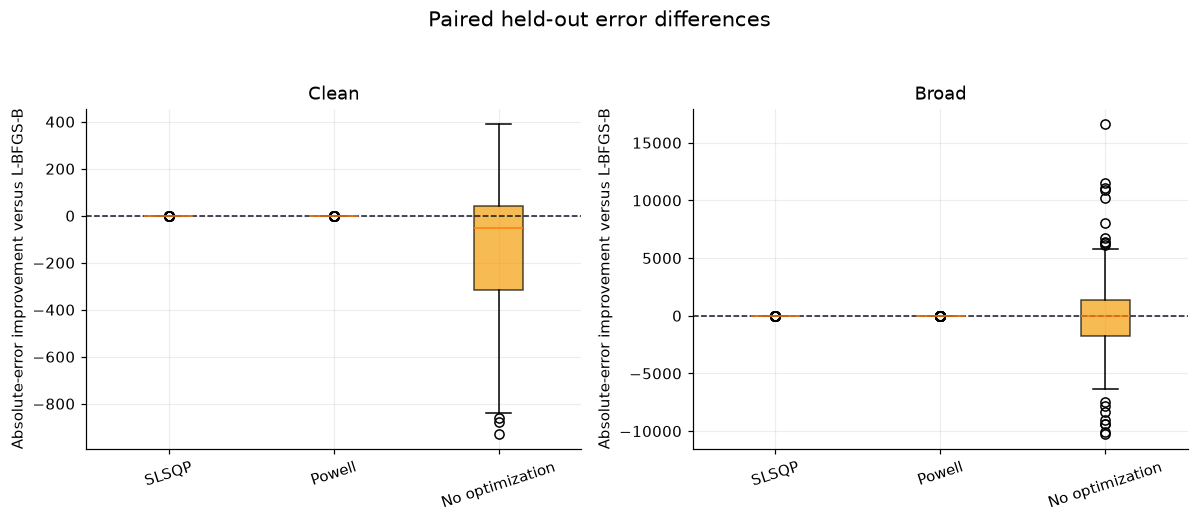

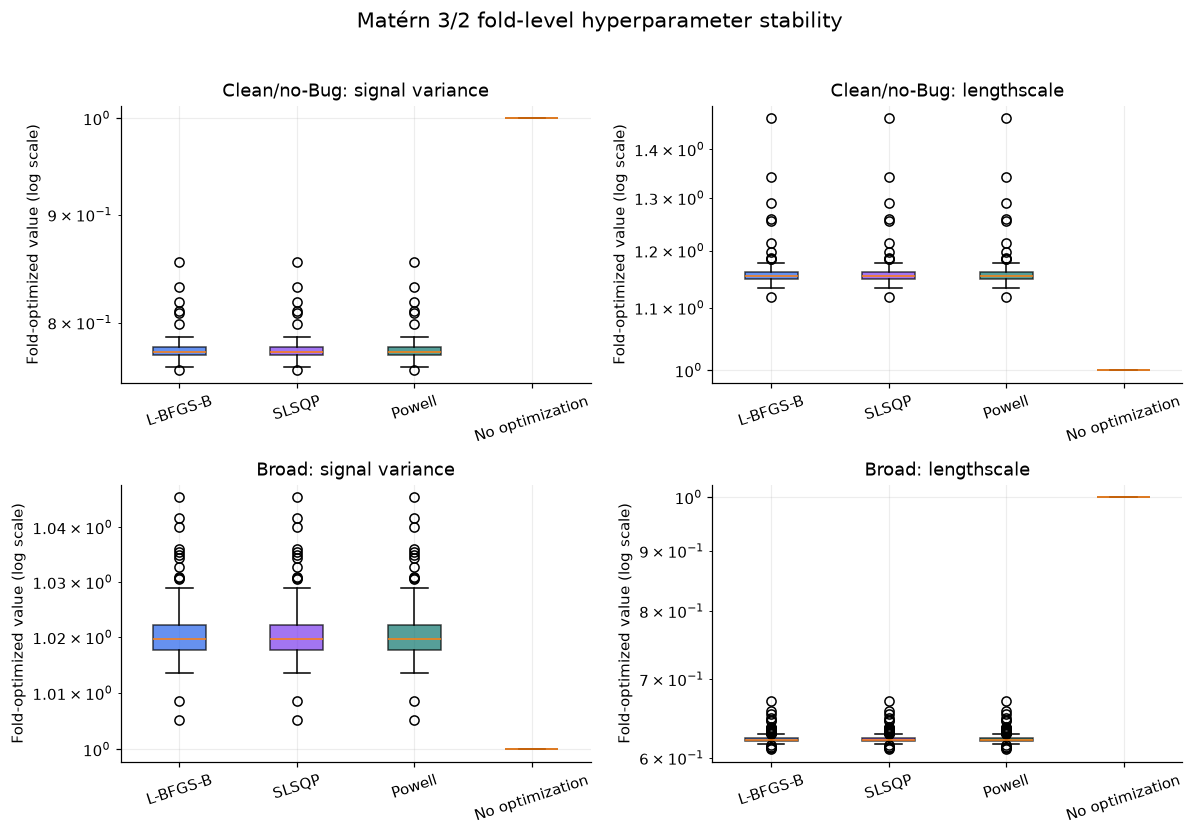

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.8), sharey=False)
for axis, dataset in zip(axes, ["clean", "broad"]):
    data = [
        paired_long.loc[(paired_long["dataset"].eq(dataset)) & (paired_long["candidate_optimizer"].eq(optimizer)), "absolute_error_improvement_lbfgsb_minus_candidate"].to_numpy()
        for optimizer in ["slsqp", "powell", "none"]
    ]
    box = axis.boxplot(data, tick_labels=[OPTIMIZER_LABELS[key] for key in ["slsqp", "powell", "none"]], patch_artist=True, showfliers=True)
    for patch, optimizer in zip(box["boxes"], ["slsqp", "powell", "none"]):
        patch.set_facecolor(OPTIMIZER_COLORS[optimizer]); patch.set_alpha(0.7)
    axis.axhline(0, color="#111827", linestyle="--", linewidth=1)
    axis.set_ylabel("Absolute-error improvement versus L-BFGS-B")
    axis.set_title(dataset.title())
    axis.tick_params(axis="x", rotation=18)
fig.suptitle("Paired held-out error differences", fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.94))
fig.savefig(OUTPUT_ROOT / "optimizer_pairwise_error_differences.png", bbox_inches="tight")
plt.show(); plt.close(fig)

fig, axes = plt.subplots(2, 2, figsize=(11.0, 7.7))
for row_index, (dataset, diagnostics) in enumerate([
    ("Clean/no-Bug", optimizer_fold_diagnostics.loc[optimizer_fold_diagnostics["dataset"].eq("clean")]),
    ("Broad", optimizer_fold_diagnostics.loc[optimizer_fold_diagnostics["dataset"].eq("broad")]),
]):
    for column_index, parameter in enumerate(["signal_variance", "lengthscale"]):
        data = [diagnostics.loc[diagnostics["optimizer"].eq(key), parameter].to_numpy() for key in OPTIMIZER_ORDER]
        box = axes[row_index, column_index].boxplot(data, tick_labels=[OPTIMIZER_LABELS[key] for key in OPTIMIZER_ORDER], patch_artist=True, showfliers=True)
        for patch, key in zip(box["boxes"], OPTIMIZER_ORDER):
            patch.set_facecolor(OPTIMIZER_COLORS[key]); patch.set_alpha(0.7)
        axes[row_index, column_index].set_yscale("log")
        axes[row_index, column_index].set_title(f"{dataset}: {parameter.replace('_', ' ')}")
        axes[row_index, column_index].tick_params(axis="x", rotation=18)
        axes[row_index, column_index].set_ylabel("Fold-optimized value (log scale)")
fig.suptitle("Matérn 3/2 fold-level hyperparameter stability", fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.96))
fig.savefig(OUTPUT_ROOT / "optimizer_hyperparameter_stability.png", bbox_inches="tight")
plt.show(); plt.close(fig)


## 9. Full-data Matérn 3/2 fits


In [12]:
def fit_full_data(dataset_name: str, data: pd.DataFrame, optimizer_name: str, nu: float) -> dict:
    scaler = StandardScaler().fit(data[INPUTS])
    X = scaler.transform(data[INPUTS])
    y = data[TARGET].to_numpy(float)
    run_records: list[dict] = []
    callable_optimizer = None if optimizer_name == "none" else make_optimizer_callable(optimizer_name, run_records)
    model = GaussianProcessRegressor(
        kernel=make_kernel(nu=nu), alpha=ALPHA, normalize_y=NORMALIZE_Y,
        optimizer=callable_optimizer, n_restarts_optimizer=0 if optimizer_name == "none" else 1,
        random_state=RANDOM_SEED,
    )
    fit_failed = False
    failure_message = ""
    fallback_fit_used = False
    began = time.perf_counter()
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        try:
            model.fit(X, y)
        except Exception as exc:
            fit_failed = True
            failure_message = f"{type(exc).__name__}: {exc}"
            fallback_fit_used = True
            model = GaussianProcessRegressor(kernel=make_kernel(nu=nu), alpha=ALPHA, normalize_y=NORMALIZE_Y, optimizer=None, random_state=RANDOM_SEED).fit(X, y)
    runtime = time.perf_counter() - began
    theta = np.asarray(model.kernel_.theta, dtype=float)
    bound_count, bound_parameters = bound_diagnostics(theta, np.asarray(model.kernel_.bounds, dtype=float))
    selected_success = True if optimizer_name == "none" else (bool(min(run_records, key=lambda row: row["objective"])["success"]) if run_records else False)
    return {
        "dataset": dataset_name,
        "kernel": f"Matern_{nu}",
        "optimizer": optimizer_name,
        "optimizer_label": OPTIMIZER_LABELS[optimizer_name],
        "training_simulations": len(data),
        "optimized_kernel_expression": str(model.kernel_),
        "log_marginal_likelihood": float(model.log_marginal_likelihood_value_),
        "signal_variance": float(np.exp(theta[0])),
        "lengthscale": float(np.exp(theta[1])),
        "fit_runtime_seconds": runtime,
        "optimizer_selected_run_success": selected_success,
        "optimizer_run_count": len(run_records),
        "optimizer_runs_json": json.dumps(run_records),
        "warning_count": len(caught),
        "warning_messages": " | ".join(f"{type(item.message).__name__}: {item.message}" for item in caught),
        "fit_failed": fit_failed,
        "fit_failure_message": failure_message,
        "fallback_fit_used": fallback_fit_used,
        "parameter_bound_hit_count": bound_count,
        "parameter_bound_hit_parameters": bound_parameters,
    }

full_fit_rows = []
for dataset_name, data in [("clean", clean_data), ("broad", broad_data)]:
    for optimizer_name in OPTIMIZER_ORDER:
        full_fit_rows.append(fit_full_data(dataset_name, data, optimizer_name, nu=1.5))
full_data_optimizer_fits = pd.DataFrame(full_fit_rows)
full_data_optimizer_fits.to_csv(OUTPUT_ROOT / "full_data_optimizer_fits.csv", index=False)
display(full_data_optimizer_fits.drop(columns="optimizer_runs_json").round(8))


,dataset,kernel,optimizer,optimizer_label,training_simulations,optimized_kernel_expression,log_marginal_likelihood,signal_variance,lengthscale,fit_runtime_seconds,optimizer_selected_run_success,optimizer_run_count,warning_count,warning_messages,fit_failed,fit_failure_message,fallback_fit_used,parameter_bound_hit_count,parameter_bound_hit_parameters
0,clean,Matern_1.5,lbfgsb,L-BFGS-B,91,"0.88**2 * Matern(length_scale=1.16, nu=1.5)",-61.617149,0.774060,1.157512,0.036508,True,2,0,,False,,False,0,
1,clean,Matern_1.5,slsqp,SLSQP,91,"0.88**2 * Matern(length_scale=1.16, nu=1.5)",-61.617149,0.774060,1.157512,0.043790,True,2,0,,False,,False,0,
2,clean,Matern_1.5,powell,Powell,91,"0.88**2 * Matern(length_scale=1.16, nu=1.5)",-61.617149,0.774060,1.157512,0.206954,True,2,0,,False,,False,0,
3,clean,Matern_1.5,none,No optimization,91,"1**2 * Matern(length_scale=1, nu=1.5)",-66.518806,1.000000,1.000000,0.001668,True,0,0,,False,,False,0,
4,broad,Matern_1.5,lbfgsb,L-BFGS-B,238,"1.01**2 * Matern(length_scale=0.623, nu=1.5)",-282.062803,1.020430,0.623225,0.310449,True,2,0,,False,,False,0,
5,broad,Matern_1.5,slsqp,SLSQP,238,"1.01**2 * Matern(length_scale=0.623, nu=1.5)",-282.062803,1.020432,0.623226,0.162226,True,2,0,,False,,False,0,
6,broad,Matern_1.5,powell,Powell,238,"1.01**2 * Matern(length_scale=0.623, nu=1.5)",-282.062803,1.020430,0.623225,0.864122,True,2,0,,False,,False,0,
7,broad,Matern_1.5,none,No optimization,238,"1**2 * Matern(length_scale=1, nu=1.5)",-332.809323,1.000000,1.000000,0.004036,True,0,0,,False,,False,0,


## 10. Broad Matérn 5/2 full-data-only optimizer sanity check


In [13]:
broad_matern52_full_data_optimizer_check = pd.DataFrame([
    fit_full_data("broad", broad_data, optimizer_name, nu=2.5)
    for optimizer_name in OPTIMIZER_ORDER
])
broad_matern52_full_data_optimizer_check.to_csv(
    OUTPUT_ROOT / "broad_matern52_full_data_optimizer_check.csv", index=False
)
display(broad_matern52_full_data_optimizer_check.drop(columns="optimizer_runs_json").round(8))


,dataset,kernel,optimizer,optimizer_label,training_simulations,optimized_kernel_expression,log_marginal_likelihood,signal_variance,lengthscale,fit_runtime_seconds,optimizer_selected_run_success,optimizer_run_count,warning_count,warning_messages,fit_failed,fit_failure_message,fallback_fit_used,parameter_bound_hit_count,parameter_bound_hit_parameters
0,broad,Matern_2.5,lbfgsb,L-BFGS-B,238,"1.01**2 * Matern(length_scale=0.554, nu=2.5)",-283.720783,1.012963,0.554473,0.355298,True,2,0,,False,,False,0,
1,broad,Matern_2.5,slsqp,SLSQP,238,"1.01**2 * Matern(length_scale=0.554, nu=2.5)",-283.720783,1.012964,0.554473,0.086629,True,2,0,,False,,False,0,
2,broad,Matern_2.5,powell,Powell,238,"1.01**2 * Matern(length_scale=0.554, nu=2.5)",-283.720783,1.012964,0.554473,1.247914,True,2,0,,False,,False,0,
3,broad,Matern_2.5,none,No optimization,238,"1**2 * Matern(length_scale=1, nu=2.5)",-454.160571,1.000000,1.000000,0.003055,True,0,0,,False,,False,0,


**Interpretation.** This Matérn 5/2 check compares full-data optimizer convergence and LML only. It does not replace the Phase 2 broad Matérn 5/2 LOO result and is not evidence that full-data LML alone selects the better predictive kernel.


## 11. Robustness conclusions


In [14]:
clean_indexed = clean_metrics.set_index("optimizer")
broad_indexed = broad_metrics.set_index("optimizer")
optimized_names = ["lbfgsb", "slsqp", "powell"]
rmse_changes = {
    name: [
        100 * (clean_indexed.loc["lbfgsb", "RMSE"] - clean_indexed.loc[name, "RMSE"]) / clean_indexed.loc["lbfgsb", "RMSE"],
        100 * (broad_indexed.loc["lbfgsb", "RMSE"] - broad_indexed.loc[name, "RMSE"]) / broad_indexed.loc["lbfgsb", "RMSE"],
    ]
    for name in optimized_names
}
material_alternative = None
for name in ["slsqp", "powell"]:
    no_failures = clean_indexed.loc[name, "failure_count"] == 0 and broad_indexed.loc[name, "failure_count"] == 0
    improves_both = min(rmse_changes[name]) > 0.5
    if no_failures and improves_both:
        material_alternative = name
        break
recommended_optimizer = material_alternative or "lbfgsb"

phase2_clean = pd.read_csv(PHASE2_CLEAN_METRICS)
phase2_broad = pd.read_csv(PHASE2_BROAD_METRICS)
phase2_other_clean_best = phase2_clean.loc[~phase2_clean["kernel_key"].eq("matern_3_2"), "RMSE"].min()
phase2_other_broad_best = phase2_broad.loc[~phase2_broad["kernel_key"].eq("matern_3_2"), "RMSE"].min()
optimized_m32_clean_best = clean_metrics.loc[clean_metrics["optimizer"].isin(optimized_names), "RMSE"].min()
optimized_m32_broad_best = broad_metrics.loc[broad_metrics["optimizer"].isin(optimized_names), "RMSE"].min()
matern32_remains_preferred = optimized_m32_clean_best < phase2_other_clean_best and optimized_m32_broad_best < phase2_other_broad_best
broad_gap_resolved = broad_metrics.loc[broad_metrics["optimizer"].isin(optimized_names), "RMSE"].min() <= 1.2 * clean_metrics.loc[clean_metrics["optimizer"].isin(optimized_names), "RMSE"].min()

best_clean_optimizer = clean_metrics.sort_values("RMSE").iloc[0]
best_broad_optimizer = broad_metrics.sort_values("RMSE").iloc[0]
display(Markdown(f'''
1. **Kernel robustness:** Matérn 3/2 remains preferred under the optimized families: **{matern32_remains_preferred}**. Its best optimizer-family RMSE is **{optimized_m32_clean_best:.2f}** on clean/no-Bug and **{optimized_m32_broad_best:.2f}** on broad, both below the best non-Matérn-3/2 Phase 2 alternative.
2. **Best numerical RMSE:** clean/no-Bug **{best_clean_optimizer.optimizer_label} ({best_clean_optimizer.RMSE:.2f})**; broad **{best_broad_optimizer.optimizer_label} ({best_broad_optimizer.RMSE:.2f})**.
3. **Material improvement:** no alternative is promoted unless it improves both datasets by more than 0.5% without failures. Recommended optimizer: **{OPTIMIZER_LABELS[recommended_optimizer]}**.
4. **L-BFGS-B default:** L-BFGS-B convergence success is **{int(clean_indexed.loc['lbfgsb','convergence_success_count'])}/{len(clean_data)}** clean and **{int(broad_indexed.loc['lbfgsb','convergence_success_count'])}/{len(broad_data)}** broad, with **{int(clean_indexed.loc['lbfgsb','failure_count'] + broad_indexed.loc['lbfgsb','failure_count'])}** fit failures.
5. **Broad-data gap:** optimizer choice resolves the much larger broad RMSE: **{broad_gap_resolved}**. Optimizer changes do not remove the subgroup/design-distribution difference.

Full-data LML is reported as a numerical diagnostic, not the sole ranking criterion.
'''))



1. **Kernel robustness:** Matérn 3/2 remains preferred under the optimized families: **True**. Its best optimizer-family RMSE is **2537.01** on clean/no-Bug and **16256.26** on broad, both below the best non-Matérn-3/2 Phase 2 alternative.
2. **Best numerical RMSE:** clean/no-Bug **Powell (2537.01)**; broad **SLSQP (16256.26)**.
3. **Material improvement:** no alternative is promoted unless it improves both datasets by more than 0.5% without failures. Recommended optimizer: **L-BFGS-B**.
4. **L-BFGS-B default:** L-BFGS-B convergence success is **91/91** clean and **238/238** broad, with **0** fit failures.
5. **Broad-data gap:** optimizer choice resolves the much larger broad RMSE: **False**. Optimizer changes do not remove the subgroup/design-distribution difference.

Full-data LML is reported as a numerical diagnostic, not the sole ranking criterion.


## 12. Save summary artifacts


In [15]:
optimizer_settings = pd.DataFrame([
    {"optimizer": "lbfgsb", "gradient": "analytic", "maxiter": MAXITER, "objective_ftol": OBJECTIVE_FTOL, "parameter_tolerance": GRADIENT_GTOL, "initial_starts": 2},
    {"optimizer": "slsqp", "gradient": "analytic", "maxiter": MAXITER, "objective_ftol": OBJECTIVE_FTOL, "parameter_tolerance": np.nan, "initial_starts": 2},
    {"optimizer": "powell", "gradient": "not used", "maxiter": MAXITER, "objective_ftol": OBJECTIVE_FTOL, "parameter_tolerance": POWELL_XTOL, "initial_starts": 2},
    {"optimizer": "none", "gradient": "not applicable", "maxiter": 0, "objective_ftol": np.nan, "parameter_tolerance": np.nan, "initial_starts": 1},
])
optimizer_settings.to_csv(OUTPUT_ROOT / "optimizer_settings.csv", index=False)

summary = {
    "experiment": "Week 5 Experiment 04 — Matérn 3/2 optimizer robustness",
    "execution_date": date.today().isoformat(),
    "raw_sha256": raw_sha256,
    "fixed_model": {
        "kernel": "ConstantKernel × Matern(nu=1.5)",
        "constant_initial": CONSTANT_INITIAL, "constant_bounds": CONSTANT_BOUNDS,
        "lengthscale_initial": LENGTHSCALE_INITIAL, "lengthscale_bounds": LENGTHSCALE_BOUNDS,
        "normalize_y": NORMALIZE_Y, "alpha_jitter": ALPHA, "white_kernel": False,
        "fold_local_scaling": True,
    },
    "optimizer_settings": optimizer_settings.to_dict(orient="records"),
    "clean_metrics": clean_metrics.to_dict(orient="records"),
    "broad_metrics": broad_metrics.to_dict(orient="records"),
    "pairwise_vs_lbfgsb": optimizer_pairwise_comparison.to_dict(orient="records"),
    "full_data_matern32": full_data_optimizer_fits.drop(columns="optimizer_runs_json").to_dict(orient="records"),
    "broad_matern52_full_data": broad_matern52_full_data_optimizer_check.drop(columns="optimizer_runs_json").to_dict(orient="records"),
    "runtime": {"clean_loo_wall_seconds": clean_loo_wall_seconds, "broad_loo_wall_seconds": broad_loo_wall_seconds},
    "conclusions": {
        "matern32_remains_preferred": bool(matern32_remains_preferred),
        "recommended_kernel": "Matern 3/2",
        "recommended_optimizer": recommended_optimizer,
        "recommended_optimizer_label": OPTIMIZER_LABELS[recommended_optimizer],
        "material_alternative_threshold_percent": 0.5,
        "broad_gap_resolved": bool(broad_gap_resolved),
        "active_learning_started": False,
        "level_set_estimation_started": False,
    },
}
def json_ready(value):
    if isinstance(value, dict):
        return {str(key): json_ready(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_ready(item) for item in value]
    if isinstance(value, np.ndarray):
        return [json_ready(item) for item in value.tolist()]
    if isinstance(value, np.generic):
        value = value.item()
    if isinstance(value, float) and not np.isfinite(value):
        return None
    return value

with (OUTPUT_ROOT / "optimizer_comparison_summary.json").open("w", encoding="utf-8") as handle:
    json.dump(json_ready(summary), handle, indent=2, ensure_ascii=False, allow_nan=False)

clean_text = clean_metrics.set_index("optimizer")
broad_text = broad_metrics.set_index("optimizer")
results_markdown = f'''# Week 5 Experiment 04 results summary

## Fixed comparison

All optimized Matérn 3/2 fits used fold-local scaling, `normalize_y=True`, `alpha=1e-6`, identical bounds, the same initial point and one identical deterministic extra restart. Powell did not use gradients; L-BFGS-B and SLSQP used analytic GP gradients. The no-optimization row is a sanity baseline.

## LOO findings

| Dataset | Optimizer | RMSE | MAE | Mean NLPD | Coverage | Runtime (s) | Successful selected runs | Failures |
|---|---|---:|---:|---:|---:|---:|---:|---:|
'''
for dataset_label, table in [("Clean/no-Bug", clean_text), ("Broad", broad_text)]:
    for optimizer_name in OPTIMIZER_ORDER:
        row = table.loc[optimizer_name]
        results_markdown += f"| {dataset_label} | {OPTIMIZER_LABELS[optimizer_name]} | {row.RMSE:.3f} | {row.MAE:.3f} | {row.mean_negative_log_predictive_density:.5f} | {row.empirical_95_interval_coverage:.3%} | {row.total_runtime_seconds:.2f} | {int(row.convergence_success_count)} | {int(row.failure_count)} |\n"
results_markdown += f'''

## Recommendation

- Kernel: **Matérn 3/2**.
- Optimizer: **{OPTIMIZER_LABELS[recommended_optimizer]}**.
- Broad-data performance gap resolved by optimizer choice: **{broad_gap_resolved}**.
- Broad Matérn 5/2 full-data results are a limited LML/convergence check, not a replacement for LOO.
- Active learning and level-set estimation were not started.
'''
(OUTPUT_ROOT / "week5_04_results_summary.md").write_text(results_markdown, encoding="utf-8")


1524

## 13. Validation


In [16]:
validation_rows = []
def check(label: str, condition: bool, evidence: str) -> None:
    validation_rows.append({"check": label, "status": "PASS" if condition else "FAIL", "evidence": evidence})
    if not condition:
        raise AssertionError(f"{label}: {evidence}")

check("raw SHA-256 unchanged", raw_sha256 == EXPECTED_SHA256, raw_sha256)
check("expected sample counts", len(clean_data) == 91 and len(broad_data) == 238, f"clean={len(clean_data)}, broad={len(broad_data)}")
check("clean prediction rows", len(clean_predictions) == 91 * 4, f"rows={len(clean_predictions)}")
check("broad prediction rows", len(broad_predictions) == 238 * 4, f"rows={len(broad_predictions)}")
check("unique clean simulation-optimizer rows", not clean_predictions.duplicated(["name", "optimizer"]).any(), "duplicates=0")
check("unique broad simulation-optimizer rows", not broad_predictions.duplicated(["name", "optimizer"]).any(), "duplicates=0")
check("finite predictive means", np.isfinite(pd.concat([clean_predictions["predicted_mean"], broad_predictions["predicted_mean"]])).all(), "finite")
check("finite positive predictive std", np.isfinite(pd.concat([clean_predictions["predicted_std"], broad_predictions["predicted_std"]])).all() and pd.concat([clean_predictions["predicted_std"], broad_predictions["predicted_std"]]).gt(0).all(), "finite and positive")
check("fold-local clean scaler", clean_predictions["scaler_fit_rows"].eq(90).all() and ~clean_predictions["heldout_in_scaler_fit"].any(), "90 training rows")
check("fold-local broad scaler", broad_predictions["scaler_fit_rows"].eq(237).all() and ~broad_predictions["heldout_in_scaler_fit"].any(), "237 training rows")

optimized_diagnostics = optimizer_fold_diagnostics.loc[optimizer_fold_diagnostics["optimizer"].isin(["lbfgsb", "slsqp", "powell"])]
parsed_runs = [run for text in optimized_diagnostics["optimizer_runs_json"] for run in json.loads(text)]
check("optimizer parameter vectors finite", all(np.isfinite(run["result_theta"]).all() for run in parsed_runs), f"runs={len(parsed_runs)}")
check("optimizer objectives finite", all(np.isfinite(run["objective"]) for run in parsed_runs), f"runs={len(parsed_runs)}")
common_start_ok = True
for (dataset, fold_index), group in optimized_diagnostics.groupby(["dataset", "fold_index"], observed=True):
    start_sets = group.set_index("optimizer")["optimizer_start_thetas_json"]
    common_start_ok &= len(set(start_sets.tolist())) == 1
check("common deterministic starts", common_start_ok, "identical across L-BFGS-B, SLSQP and Powell in every fold")
check("failed fits explicitly recorded", optimizer_fold_diagnostics["fit_failed"].notna().all() and optimizer_fold_diagnostics["fit_failure_message"].notna().all(), f"failed={int(optimizer_fold_diagnostics['fit_failed'].sum())}")
check("matching model specification", pd.concat([clean_predictions, broad_predictions])["alpha_jitter"].eq(ALPHA).all() and pd.concat([clean_predictions, broad_predictions])["normalize_y"].all(), "alpha and normalize_y match")
check("full Matérn 3/2 fits", len(full_data_optimizer_fits) == 8, "2 datasets × 4 optimizers")
check("broad Matérn 5/2 check", len(broad_matern52_full_data_optimizer_check) == 4, "4 full-data fits")
check("metric tables saved", (OUTPUT_ROOT / "clean_optimizer_metrics.csv").exists() and (OUTPUT_ROOT / "broad_optimizer_metrics.csv").exists(), "present")
check("no model binaries", not any(OUTPUT_ROOT.rglob("*.pkl")) and not any(OUTPUT_ROOT.rglob("*.joblib")), "none")
check("out-of-scope methods not started", summary["conclusions"]["active_learning_started"] is False and summary["conclusions"]["level_set_estimation_started"] is False, "not started")

validation = pd.DataFrame(validation_rows)
validation.to_csv(OUTPUT_ROOT / "validation_results.csv", index=False)
display(validation)


,check,status,evidence
0,raw SHA-256 unchanged,PASS,964a12d86435e9f0879e2e43384d997e1cc2faa7b9e4c3...
1,expected sample counts,PASS,"clean=91, broad=238"
2,clean prediction rows,PASS,rows=364
3,broad prediction rows,PASS,rows=952
4,unique clean simulation-optimizer rows,PASS,duplicates=0
5,unique broad simulation-optimizer rows,PASS,duplicates=0
6,finite predictive means,PASS,finite
7,finite positive predictive std,PASS,finite and positive
8,fold-local clean scaler,PASS,90 training rows
9,fold-local broad scaler,PASS,237 training rows


## 14. What we learned

The tables above show whether different bounded optimizers materially change held-out Matérn 3/2 predictions, uncertainty intervals, hyperparameters, convergence behavior or runtime. Full-data log marginal likelihood is retained as a numerical diagnostic but does not replace LOO.

## What this means for the thesis

The final optimizer recommendation should favor held-out robustness and numerical stability over tiny metric differences. The broad/no-Bug performance difference remains a data-subgroup issue unless an optimizer changes it materially across the same held-out protocol.

## What remains unresolved

This experiment does not test active learning, level-set estimation, GP classification, ARD Matérn kernels or additional optimizer families. The first-observed-Conduction raw-timestep target remains fixed.
